# Notebook 05 — Transfer Learning (ResNet-50)

We replace the baseline CNN with a pretrained ResNet-50 — a deep network already trained on 1.2 million images.
Instead of learning from scratch, we adapt what ResNet-50 already knows to chest X-ray classification.

**Two-phase training strategy:**
- **Phase A (3 epochs):** Freeze the entire ResNet-50 backbone. Only train the final classification layer. This warms up the classifier before the pretrained weights are touched.
- **Phase B (15 epochs):** Unfreeze everything. Fine-tune the full network at a much lower learning rate so pretrained weights adapt gradually rather than getting destroyed.

We also add **threshold tuning** — instead of defaulting to 0.5, we find the optimal decision threshold on the validation set and apply it to the test set.

---

**Before running**, make sure:
- Credentials file is at `configs/nih-xray-ml-8be81f9160f0.json`
- `IMAGE_DIR` in Step 1 points to your local image folder

## Step 0 — Install dependencies

In [22]:
%pip install torch torchvision scikit-learn google-cloud-bigquery google-cloud-storage google-auth db-dtypes pyarrow pandas Pillow matplotlib --quiet


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Connect to Google Cloud

In [23]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from google.cloud import bigquery
from google.oauth2 import service_account

CRED_FILENAME = "nih-xray-ml-8be81f9160f0.json"
PROJECT_ID    = "nih-xray-ml"

# --- SET THIS TO YOUR LOCAL IMAGE FOLDER ---
# Kaggle download on SSD (all 112K images):
#   IMAGE_DIR = Path("/Volumes/T7 Shield/x-ray-datasets/archive/images_006/images")
# Teammates (downloaded from GCS via notebook 03):
#   IMAGE_DIR = Path("../../data/images")
IMAGE_DIR = Path("/Volumes/T7 Shield/x-ray-datasets/archive/images_006/images")

# Cap images per split. Set to None to use all available (recommended with GPU).
MAX_PER_SPLIT = 1000

search_roots = [Path.cwd(), *Path.cwd().parents[:4]]
cred_path = next(
    (r / "configs" / CRED_FILENAME for r in search_roots if (r / "configs" / CRED_FILENAME).exists()),
    None
)

if cred_path is None:
    raise FileNotFoundError(f"Could not find '{CRED_FILENAME}' in any configs/ folder.")

credentials = service_account.Credentials.from_service_account_file(str(cred_path))
bq_client   = bigquery.Client(project=PROJECT_ID, credentials=credentials)
print("Connected to BigQuery.")
print(f"Image directory:      {IMAGE_DIR}")
print(f"Max images per split: {MAX_PER_SPLIT}")

Connected to BigQuery.
Image directory:      /Volumes/T7 Shield/x-ray-datasets/archive/images_006/images
Max images per split: 1000


## Step 2 — Rebuild the labeled dataset

In [24]:
from sklearn.model_selection import train_test_split

query = """
SELECT `Image Index`, `Finding Labels`
FROM `nih-xray-ml.nih_xray.metadata`
"""
df = bq_client.query(query).to_dataframe(create_bqstorage_client=False)

df["disease_present"] = (df["Finding Labels"] != "No Finding").astype(int)
df["patient_id"]      = df["Image Index"].str.split("_").str[0]

patients = df["patient_id"].unique()
train_patients, temp_patients = train_test_split(patients, test_size=0.30, random_state=42)
val_patients,   test_patients = train_test_split(temp_patients, test_size=0.50, random_state=42)

df["split"] = "train"
df.loc[df["patient_id"].isin(val_patients),  "split"] = "val"
df.loc[df["patient_id"].isin(test_patients), "split"] = "test"

print(f"Total images in metadata: {len(df):,}")

Total images in metadata: 112,120


## Step 3 — Filter to locally available images

In [25]:
local_filenames = set(p.name for p in IMAGE_DIR.glob("*.png"))
image_path_map  = {p.name: p for p in IMAGE_DIR.glob("*.png")}

print(f"Total images found on disk: {len(local_filenames):,}")

df_available = df[df["Image Index"].isin(local_filenames)].reset_index(drop=True)

if MAX_PER_SPLIT is not None:
    parts = []
    for split in ["train", "val", "test"]:
        subset = df_available[df_available["split"] == split]
        parts.append(subset.sample(n=min(MAX_PER_SPLIT, len(subset)), random_state=42))
    df_available = pd.concat(parts).reset_index(drop=True)

print(f"Images with metadata: {len(df_available):,}")
print()
for split in ["train", "val", "test"]:
    subset = df_available[df_available["split"] == split]
    print(f"{split:6}: {len(subset):5,} images | {subset['disease_present'].mean():.1%} disease")

Total images found on disk: 10,000
Images with metadata: 3,000

train : 1,000 images | 46.2% disease
val   : 1,000 images | 48.2% disease
test  : 1,000 images | 50.2% disease


## Step 4 — Build DataLoaders

In [26]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class XRayDataset(Dataset):
    def __init__(self, df, image_path_map, transform=None):
        self.df             = df.reset_index(drop=True)
        self.image_path_map = image_path_map
        self.transform      = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self.image_path_map[row["Image Index"]]).convert("RGB")
        label = int(row["disease_present"])
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = XRayDataset(df_available[df_available["split"] == "train"], image_path_map, train_transform)
val_dataset   = XRayDataset(df_available[df_available["split"] == "val"],   image_path_map, val_test_transform)
test_dataset  = XRayDataset(df_available[df_available["split"] == "test"],  image_path_map, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 32
Val batches:   32
Test batches:  32


## Step 5 — Load pretrained ResNet-50

We load ResNet-50 with ImageNet weights and replace the final fully connected layer
with a single output neuron for binary classification.

Everything else stays exactly as pretrained — all the feature detection knowledge is preserved.

In [27]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet50(weights=ResNet50_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 1)  # replace final layer for binary output
model = model.to(device)

print(f"Device: {device}")
print(f"Total parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Device: cpu
Total parameters:     23,510,081
Trainable parameters: 23,510,081


gsutil -m cp "/Volumes/T7 Shield/x-ray-datasets/archive/images_006/images/*.png" gs://nih-xray-images-mdfnb/images/

## Step 6 — Phase A: Train classifier only (frozen backbone)

We freeze all ResNet-50 layers and only allow the final classification layer to update.
This lets the classifier learn a reasonable mapping before we touch the pretrained weights.

In [28]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

criterion    = nn.BCEWithLogitsLoss()
optimizer_A  = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
N_EPOCHS_A   = 3

history_A = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"Phase A: training final layer only for {N_EPOCHS_A} epochs")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print()

for epoch in range(1, N_EPOCHS_A + 1):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device)
        optimizer_A.zero_grad()
        loss = criterion(model(images).squeeze(1), labels)
        loss.backward()
        optimizer_A.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().to(device)
            outputs = model(images).squeeze(1)
            val_loss += criterion(outputs, labels).item()
            preds    = (torch.sigmoid(outputs) >= 0.5).long()
            correct  += (preds == labels.long()).sum().item()
            total    += labels.size(0)
    val_loss /= len(val_loader)
    val_acc   = correct / total

    history_A["train_loss"].append(train_loss)
    history_A["val_loss"].append(val_loss)
    history_A["val_acc"].append(val_acc)
    print(f"Epoch {epoch}/{N_EPOCHS_A} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

print("\nPhase A complete.")

Phase A: training final layer only for 3 epochs
Trainable parameters: 2,049



KeyboardInterrupt: 

## Step 7 — Phase B: Fine-tune the full network

We unfreeze all layers and train the entire network at a much lower learning rate (1e-5 vs 1e-3).
The low LR ensures pretrained weights shift gradually rather than being overwritten.

In [19]:
# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

optimizer_B = torch.optim.Adam(model.parameters(), lr=1e-5)
N_EPOCHS_B  = 15

history_B = {"train_loss": [], "val_loss": [], "val_acc": []}

print(f"Phase B: fine-tuning full network for {N_EPOCHS_B} epochs at lr=1e-5")
print()

for epoch in range(1, N_EPOCHS_B + 1):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device)
        optimizer_B.zero_grad()
        loss = criterion(model(images).squeeze(1), labels)
        loss.backward()
        optimizer_B.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().to(device)
            outputs = model(images).squeeze(1)
            val_loss += criterion(outputs, labels).item()
            preds    = (torch.sigmoid(outputs) >= 0.5).long()
            correct  += (preds == labels.long()).sum().item()
            total    += labels.size(0)
    val_loss /= len(val_loader)
    val_acc   = correct / total

    history_B["train_loss"].append(train_loss)
    history_B["val_loss"].append(val_loss)
    history_B["val_acc"].append(val_acc)
    print(f"Epoch {epoch:2d}/{N_EPOCHS_B} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}")

print("\nPhase B complete.")

Phase B: fine-tuning full network for 15 epochs at lr=1e-5



KeyboardInterrupt: 

## Step 8 — Plot learning curves

We plot both phases together so you can see the transition from frozen to fine-tuning.

ValueError: x and y must have same first dimension, but have shapes (18,) and (0,)

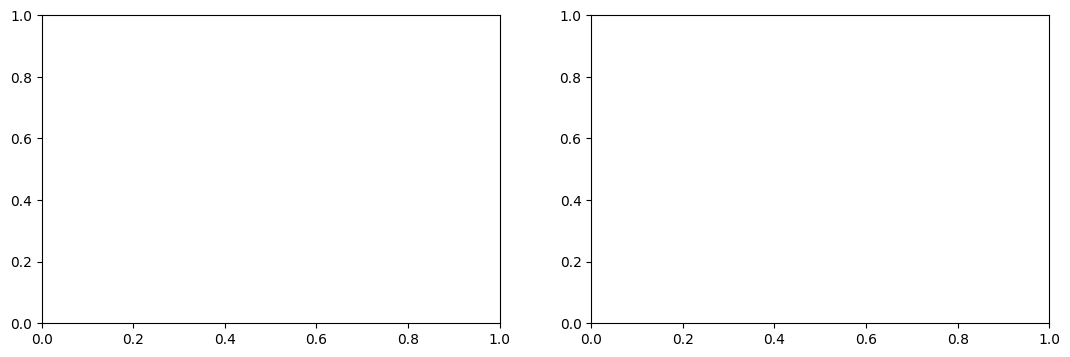

In [21]:
train_loss_all = history_A["train_loss"] + history_B["train_loss"]
val_loss_all   = history_A["val_loss"]   + history_B["val_loss"]
val_acc_all    = history_A["val_acc"]    + history_B["val_acc"]
epochs_all     = range(1, N_EPOCHS_A + N_EPOCHS_B + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_all, train_loss_all, label="Train")
ax1.plot(epochs_all, val_loss_all,   label="Val")
ax1.axvline(x=N_EPOCHS_A, color="gray", linestyle="--", label="Phase A → B")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs_all, val_acc_all)
ax2.axvline(x=N_EPOCHS_A, color="gray", linestyle="--", label="Phase A → B")
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylim(0, 1)
ax2.legend()

plt.suptitle("ResNet-50 Transfer Learning — Learning Curves")
plt.tight_layout()
plt.show()

## Step 9 — Threshold tuning on validation set

The default threshold of 0.5 is arbitrary. On an imbalanced clinical problem, reporting fixed-0.5
metrics as final results is misleading — the optimal threshold depends on whether we prioritize
recall (catching every disease case) or precision (only flagging confident cases).

We sweep thresholds from 0.01 to 0.99 on the **validation set**, find the one that maximizes F1,
then apply that threshold to the **test set**.

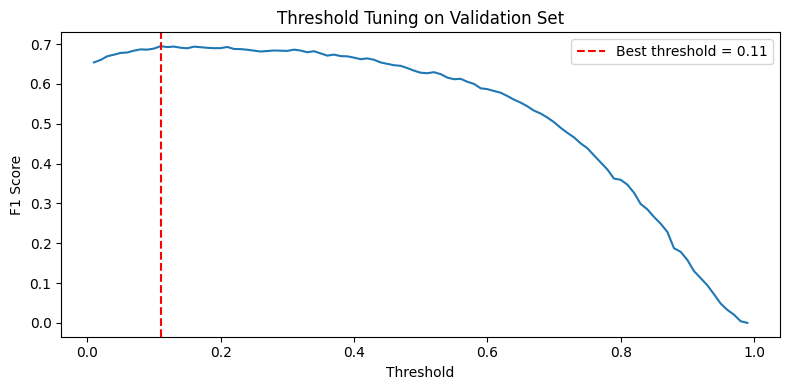

Best threshold: 0.11
Best val F1:    0.695


In [ ]:
from sklearn.metrics import f1_score

model.eval()
val_labels, val_probs = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images  = images.to(device)
        outputs = model(images).squeeze(1)
        probs   = torch.sigmoid(outputs).cpu().numpy()
        val_probs.extend(probs)
        val_labels.extend(labels.numpy())

val_probs  = np.array(val_probs)
val_labels = np.array(val_labels)

thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores  = [f1_score(val_labels, (val_probs >= t).astype(int), zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(x=best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Tuning on Validation Set")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best val F1:    {best_f1:.3f}")

## Step 10 — Evaluate on test set

We apply the optimal threshold found on validation to the held-out test set.
These are the official Phase 5 results to compare against the baseline.

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

model.eval()
all_labels, all_probs = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images).squeeze(1)
        probs   = torch.sigmoid(outputs).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs >= best_threshold).astype(int)

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall    = recall_score(all_labels, all_preds, zero_division=0)
f1        = f1_score(all_labels, all_preds, zero_division=0)
roc_auc   = roc_auc_score(all_labels, all_probs)

print("=" * 40)
print("  RESNET-50 TRANSFER LEARNING RESULTS")
print("=" * 40)
print(f"  Threshold: {best_threshold:.2f} (tuned on val)")
print(f"  Accuracy:  {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1:        {f1:.3f}")
print(f"  ROC-AUC:   {roc_auc:.3f}")
print("=" * 40)
print()
print("  BASELINE CNN (for comparison)")
print(f"  Threshold: 0.50 (fixed)")
print(f"  Accuracy:  0.577")
print(f"  ROC-AUC:   0.611")
print("=" * 40)

  RESNET-50 TRANSFER LEARNING RESULTS
  Threshold: 0.11 (tuned on val)
  Accuracy:  0.615
  Precision: 0.574
  Recall:    0.904
  F1:        0.702
  ROC-AUC:   0.705

  BASELINE CNN (for comparison)
  Threshold: 0.50 (fixed)
  Accuracy:  0.577
  ROC-AUC:   0.611


## Step 11 — Confusion matrix and ROC curve

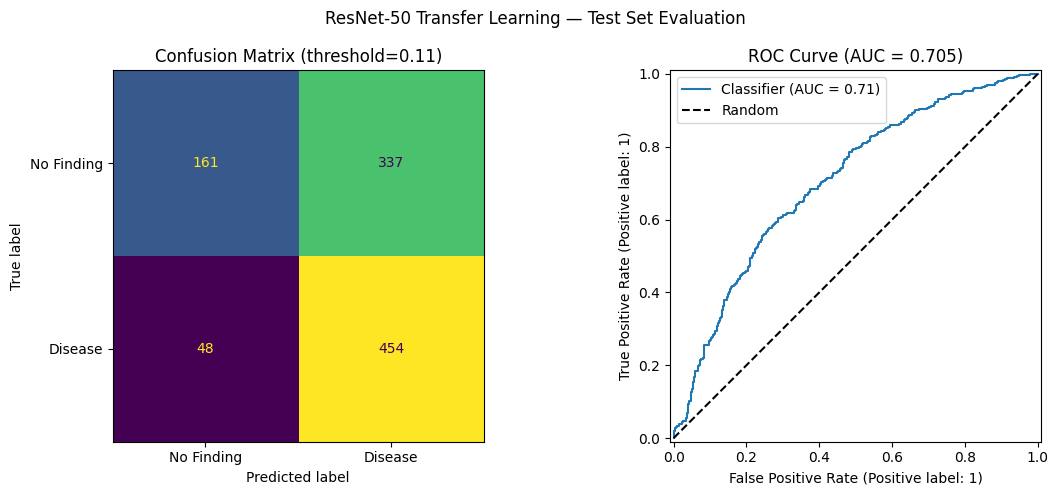

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Finding", "Disease"]).plot(ax=ax1, colorbar=False)
ax1.set_title(f"Confusion Matrix (threshold={best_threshold:.2f})")

RocCurveDisplay.from_predictions(all_labels, all_probs, ax=ax2)
ax2.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
ax2.plot([0, 1], [0, 1], "k--", label="Random")
ax2.legend()

plt.suptitle("ResNet-50 Transfer Learning — Test Set Evaluation")
plt.tight_layout()
plt.show()

## Step 12 — Save model and predictions for Phase 6

We save the trained model weights and test-set predictions to disk so Phase 6 can load them
without re-running the full training pipeline.

In [20]:
import os

MODELS_DIR = Path("../../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), MODELS_DIR / "resnet50_phase5.pt")

# Save test-set predictions and best threshold for Phase 6
df_preds = pd.DataFrame({
    "true_label":   all_labels,
    "prob_disease": all_probs,
})
df_preds.to_csv(MODELS_DIR / "predictions_resnet50.csv", index=False)

# Save threshold
with open(MODELS_DIR / "best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print(f"Saved model weights  -> models/resnet50_phase5.pt")
print(f"Saved predictions    -> models/predictions_resnet50.csv  ({len(df_preds)} rows)")
print(f"Saved threshold      -> models/best_threshold.txt  ({best_threshold:.2f})")

NameError: name 'all_labels' is not defined